In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/data.csv')

print(df.shape)
print(df.dtypes)
print(df.head())

(95662, 16)
TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object
         TransactionId         BatchId       AccountId       SubscriptionId  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  Subscriptio

In [2]:
df.describe()
df.describe(include='object')

C:\Users\HP EliteBook\AppData\Local\Temp\ipykernel_8188\754461004.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,ProviderId,ProductId,ProductCategory,ChannelId,TransactionStartTime
count,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662
unique,95662,94809,3633,3627,3742,1,6,23,9,4,94556
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,ProviderId_4,ProductId_6,financial_services,ChannelId_3,2018-12-24T16:30:13Z
freq,1,28,30893,32630,4091,95662,38189,32635,45405,56935,17


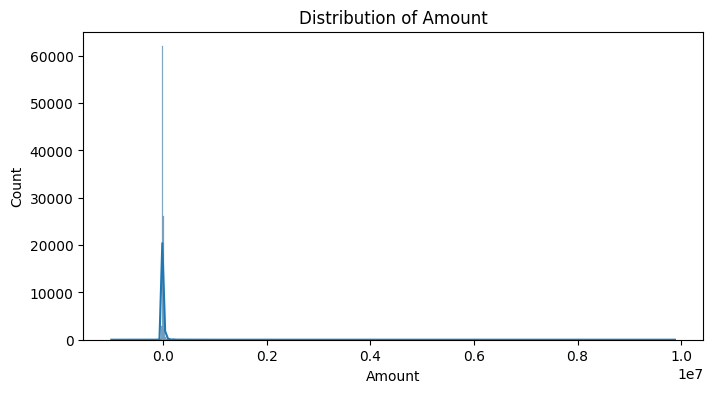

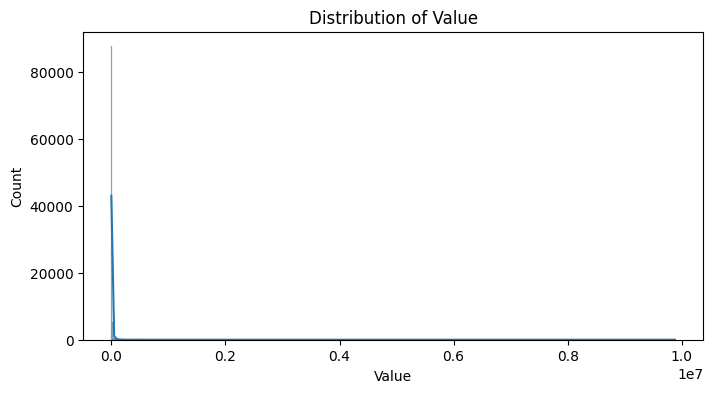

In [3]:
numerical_cols = ['Amount', 'Value']

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

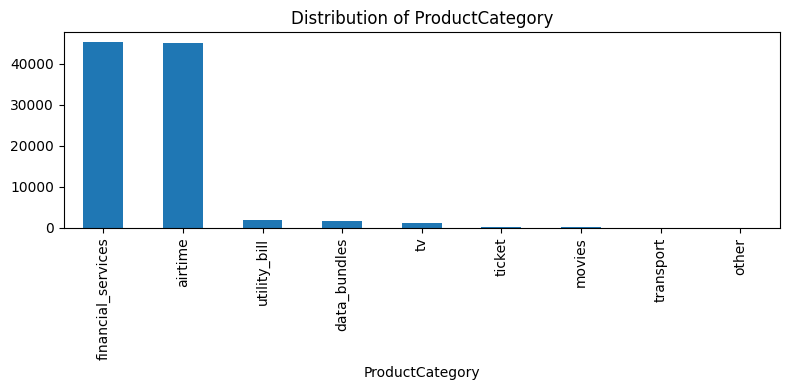

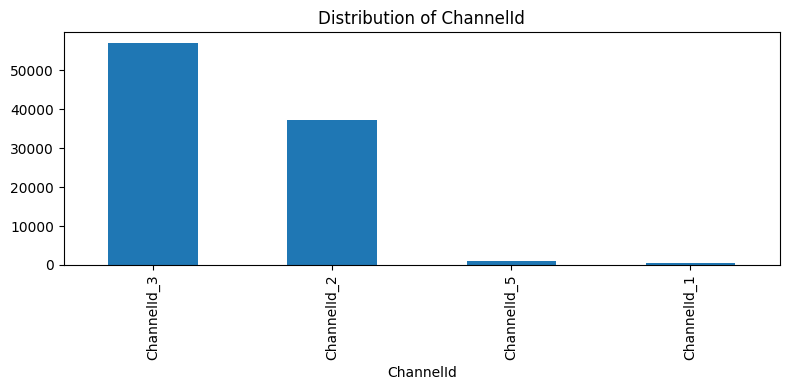

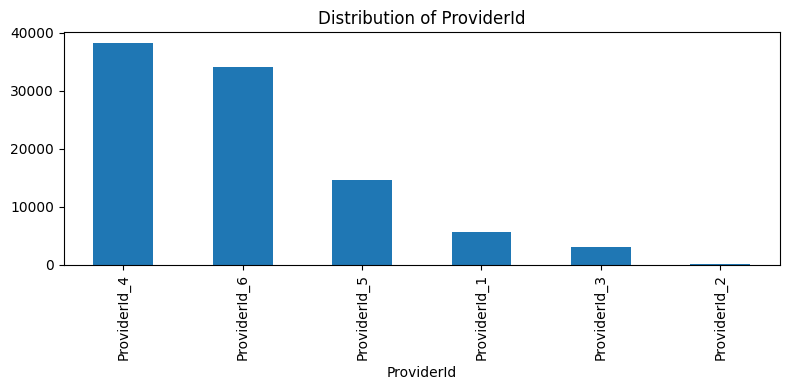

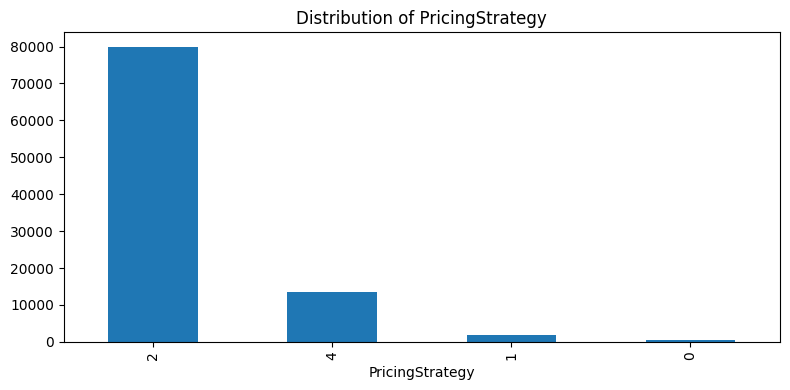

In [4]:
categorical_cols = ['ProductCategory', 'ChannelId', 'ProviderId', 'PricingStrategy']

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

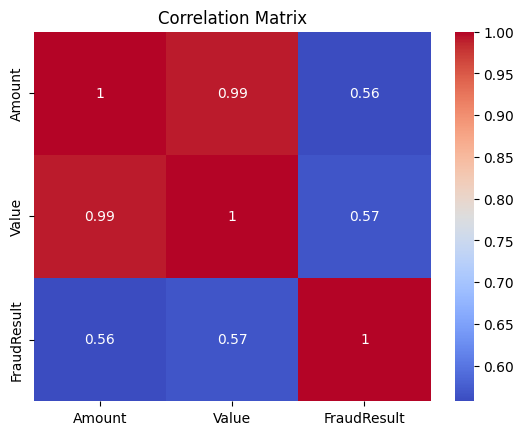

In [5]:
corr = df[['Amount', 'Value', 'FraudResult']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print(pd.concat([missing, missing_pct], axis=1, keys=['Missing', 'Percent']))

                      Missing  Percent
TransactionId               0      0.0
BatchId                     0      0.0
AccountId                   0      0.0
SubscriptionId              0      0.0
CustomerId                  0      0.0
CurrencyCode                0      0.0
CountryCode                 0      0.0
ProviderId                  0      0.0
ProductId                   0      0.0
ProductCategory             0      0.0
ChannelId                   0      0.0
Amount                      0      0.0
Value                       0      0.0
TransactionStartTime        0      0.0
PricingStrategy             0      0.0
FraudResult                 0      0.0


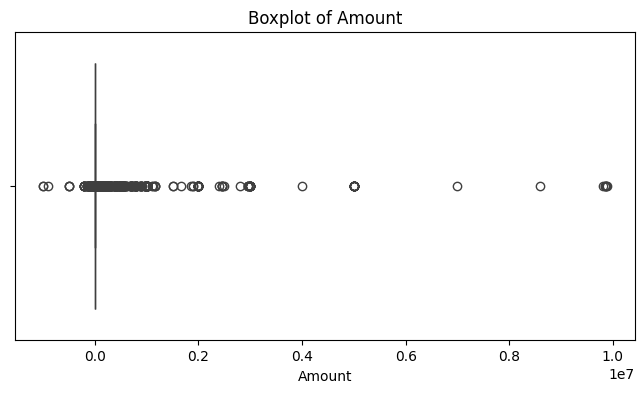

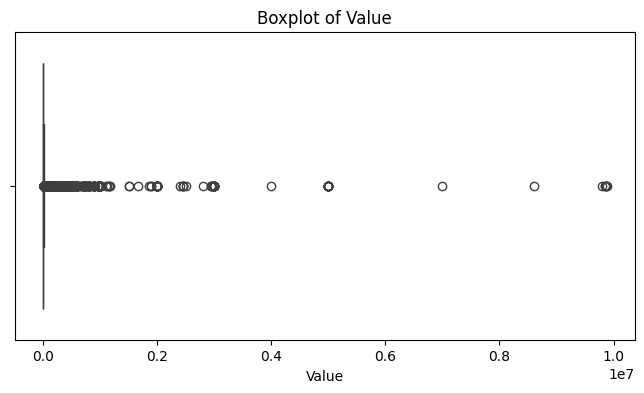

In [7]:
for col in ['Amount', 'Value']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## Key Insights

1. **Skewed distributions**: Amount and Value are heavily right-skewed — log transformation will be needed.
2. **Low fraud rate**: FraudResult is heavily imbalanced (~1–2% fraud) — model training must account for class imbalance.
3. **Dominant categories**: A small number of ProductCategory values account for most transactions.
4. **No missing values**: The dataset has no null values, so no imputation strategy is needed.
5. **Outliers present**: Extreme values exist in Amount — these could be legitimate high-value transactions or errors and need investigation.